# Quarantine Dilemma

Evaluated test cases:
- `TRANS-01`
- `TRANS-02`

In [6]:
import re
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("../../src").resolve()))
from faultlab.analysis import (
    load_csv,
    get_base_01_summary,
    get_trans_01_summary_df,
    get_trans_02_summary_df,
    QUARANTINE_MODES,
    QUARANTINE_COLORS,
)

EVALUATION_DIR = Path("../../tests/results/EVALUATION")
BASE_01_DIR = EVALUATION_DIR.joinpath("1_BASELINE/BASE_01")
TRANS_01_DIR = EVALUATION_DIR.joinpath("2_QUARANTINE_DILEMMA/TRANS_01")
TRANS_02_DIR = EVALUATION_DIR.joinpath("2_QUARANTINE_DILEMMA/TRANS_02")
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

base_caps = get_base_01_summary(BASE_01_DIR)
TPS_BASE_SIGNING = base_caps["signing_tps"]
TPS_BASE_HOT = base_caps["hot_signing_tps"]

print("=== Baseline Capacities (CIRCUIT_BREAKER) ===")
print(f"Full Signing Throughput:        {TPS_BASE_SIGNING} TPS")
print(f"Hot-Phase Signing Throughput:   {TPS_BASE_HOT} TPS (Tx 501 to 1000 steady-state)")

plt.style.use("seaborn-v0_8-whitegrid")

=== Baseline Capacities (CIRCUIT_BREAKER) ===
Full Signing Throughput:        79.63 TPS
Hot-Phase Signing Throughput:   118.83 TPS (Tx 501 to 1000 steady-state)


## 1. Table 2: `TRANS-01` Throughput Degradation

In [7]:
trans_01_df = get_trans_01_summary_df(TRANS_01_DIR, base_tps=TPS_BASE_SIGNING)
print("=== TRANS-01 Micro-Jitter Throughput Degradation ===")
display(trans_01_df)

=== TRANS-01 Micro-Jitter Throughput Degradation ===


,Quarantine Mode,Failure Rate (% per round),Cumulative Failure Rate (% per transaction),Signing Throughput (TPS),Failover Success Rate (%),Throughput Degradation (%)
0,CIRCUIT_BREAKER,3,11.47,40.64,100.0,48.96
1,CIRCUIT_BREAKER,16,50.21,16.47,100.0,79.32
2,CIRCUIT_BREAKER,44,90.17,49.62,100.0,37.68
3,DISABLED,3,11.47,40.23,100.0,49.48
4,DISABLED,16,50.21,10.41,100.0,86.93
5,DISABLED,44,90.17,5.47,100.0,93.13
6,SOFT,3,11.47,84.08,100.0,0.00
7,SOFT,16,50.21,80.60,100.0,0.00
8,SOFT,44,90.17,80.11,100.0,0.00


## 2. Figure 4: Signing Throughput Under `TRANS-01`

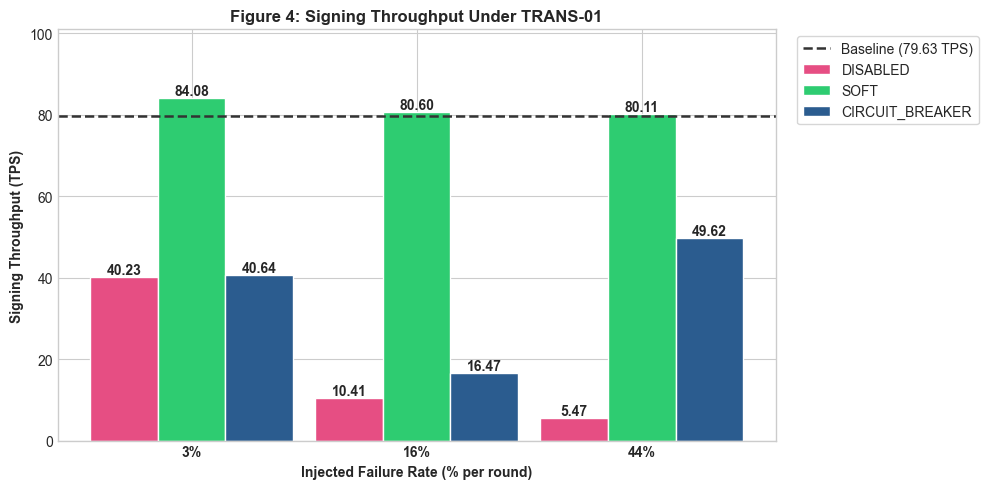

In [8]:
def fig_4():
    fig, ax = plt.subplots(figsize=(10, 5))
    drop_rates = sorted(trans_01_df["Failure Rate (% per round)"].unique())
    modes = ["DISABLED", "SOFT", "CIRCUIT_BREAKER"]
    x = np.arange(len(drop_rates), dtype=float)
    width = 0.3

    for i, mode in enumerate(modes):
        sub = trans_01_df[trans_01_df["Quarantine Mode"] == mode]
        vals = [
            (
                sub[sub["Failure Rate (% per round)"] == dr]["Signing Throughput (TPS)"].values[0]
                if not sub[sub["Failure Rate (% per round)"] == dr].empty
                else 0.0
            )
            for dr in drop_rates
        ]
        rects = ax.bar(x + (i - 1) * width, vals, width, label=mode, color=QUARANTINE_COLORS[mode], edgecolor="white")
        for rect in rects:
            h = rect.get_height()
            ax.annotate(f"{h:.2f}", xy=(rect.get_x() + rect.get_width()/2, h),  ha="center", va="bottom", fontweight="bold")

    ax.axhline(y=TPS_BASE_SIGNING, color="#333333", linestyle="--", linewidth=1.8, label=f"Baseline ({TPS_BASE_SIGNING:.2f} TPS)")
    ax.set_title("Figure 4: Signing Throughput Under TRANS-01", fontweight="bold")
    ax.set_xlabel("Injected Failure Rate (% per round)", fontweight="bold")
    ax.set_ylabel("Signing Throughput (TPS)", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{dr}%" for dr in drop_rates], fontweight="bold")
    ax.set_ylim(0, max(trans_01_df["Signing Throughput (TPS)"].max(), TPS_BASE_SIGNING) * 1.2)

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR.joinpath("FIG_4_TRANS_01_Degradation.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

fig_4()

## 3. Figure 5: Signing Recovery Trajectories Under `TRANS-02`

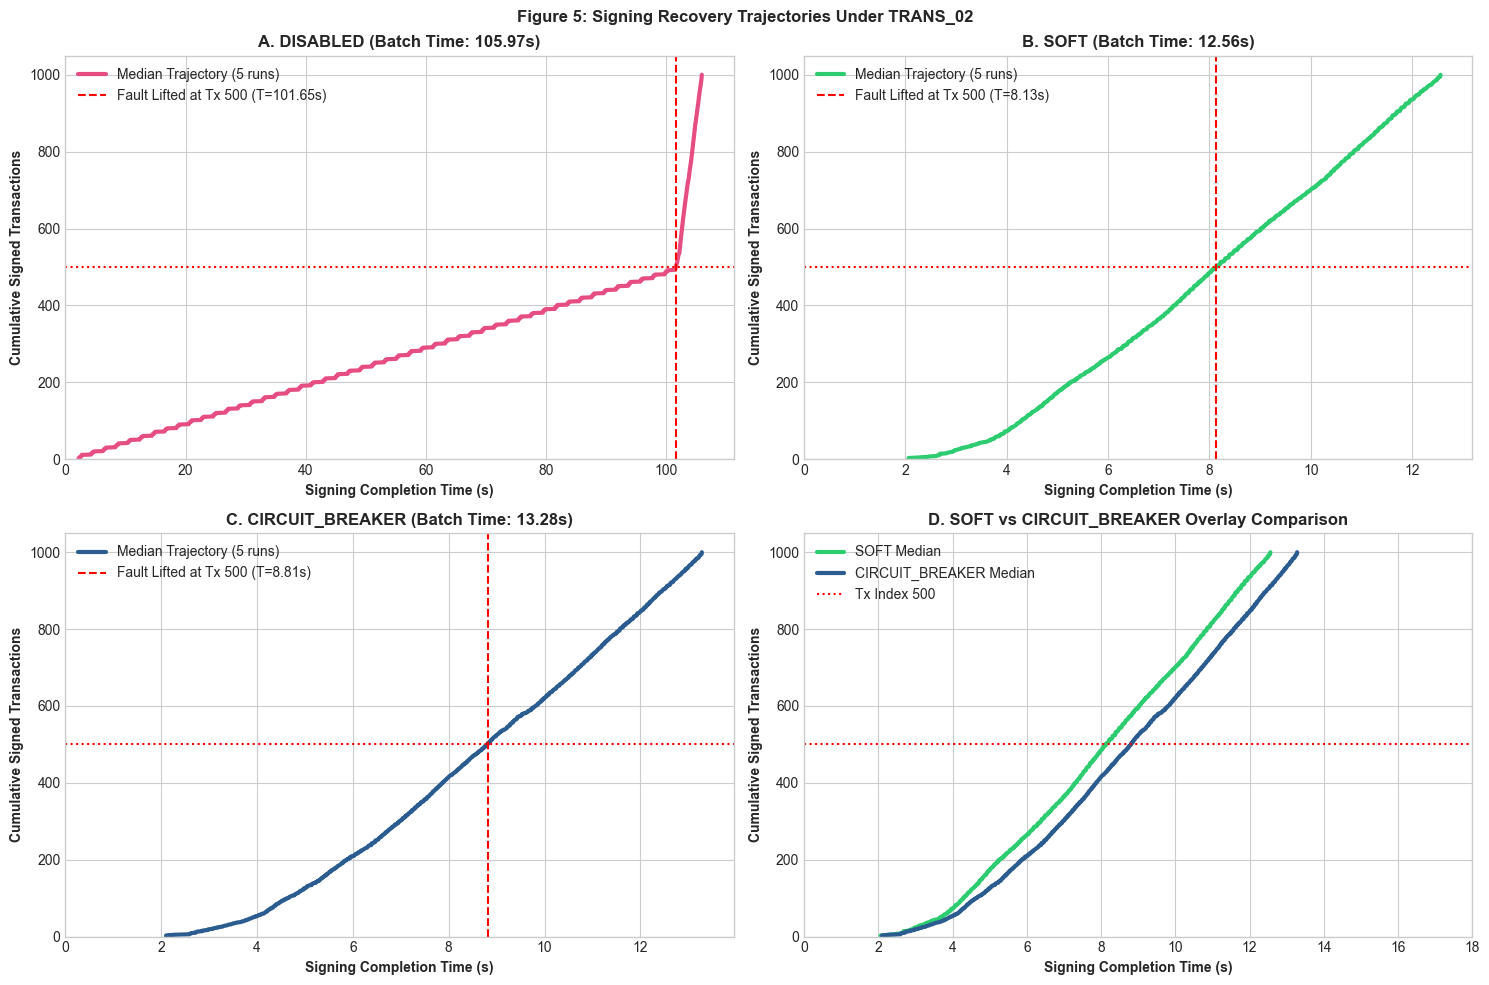

In [9]:
def fig_5():
    pattern = re.compile(r"quarantine_(disabled|soft|circuit_breaker)")
    runs_by_mode = {"DISABLED": [], "SOFT": [], "CIRCUIT_BREAKER": []}

    for file_path in sorted(TRANS_02_DIR.glob("*.csv")):
        match = pattern.search(file_path.name)
        if not match:
            continue
        mode = QUARANTINE_MODES.get(match.group(1), match.group(1))
        df = load_csv(file_path)
        sub = df[df["signed_at"].notna()].copy()
        if sub.empty:
            continue
        t0 = df["created_at"].min()
        sub["seconds_from_start"] = (sub["signed_at"] - t0).dt.total_seconds()
        sub = sub.sort_values("seconds_from_start")
        runs_by_mode[mode].append(sub)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    modes = ["DISABLED", "SOFT", "CIRCUIT_BREAKER"]
    panel_titles = ["A. DISABLED", "B. SOFT", "C. CIRCUIT_BREAKER"]

    for i, mode in enumerate(modes):
        ax = axes[i // 2, i % 2]
        runs = runs_by_mode[mode]
        if not runs:
            continue

        med_times = np.median([r["seconds_from_start"].values for r in runs], axis=0)
        med_fault = float(med_times[499])
        med_batch = float(med_times[-1])

        ax.plot(med_times, range(1, 1001), color=QUARANTINE_COLORS[mode], linewidth=3, label=f"Median Trajectory ({len(runs)} runs)")
        ax.axvline(x=med_fault, color="red", linestyle="--", linewidth=1.5, label=f"Fault Lifted at Tx 500 (T={med_fault:.2f}s)")
        ax.axhline(y=500, color="red", linestyle=":", linewidth=1.5)

        ax.set_title(f"{panel_titles[i]} (Batch Time: {med_batch:.2f}s)", fontweight="bold")
        ax.set_xlabel("Signing Completion Time (s)", fontweight="bold")
        ax.set_ylabel("Cumulative Signed Transactions", fontweight="bold")
        ax.set_xlim(0, med_batch * 1.05)
        ax.set_ylim(0, 1050)
        ax.legend(loc="upper left")

    ax_d = axes[1, 1]
    for mode in ["SOFT", "CIRCUIT_BREAKER"]:
        runs = runs_by_mode[mode]
        if not runs:
            continue
        med_times = np.median([r["seconds_from_start"].values for r in runs], axis=0)
        ax_d.plot(med_times, range(1, 1001), color=QUARANTINE_COLORS[mode], linewidth=3, label=f"{mode} Median")

    ax_d.axhline(y=500, color="red", linestyle=":", linewidth=1.5, label="Tx Index 500")
    ax_d.set_title("D. SOFT vs CIRCUIT_BREAKER Overlay Comparison", fontweight="bold")
    ax_d.set_xlabel("Signing Completion Time (s)", fontweight="bold")
    ax_d.set_ylabel("Cumulative Signed Transactions", fontweight="bold")
    ax_d.set_xlim(0, 18.0)
    ax_d.set_ylim(0, 1050)
    ax_d.legend(loc="upper left")

    plt.suptitle("Figure 5: Signing Recovery Trajectories Under TRANS_02", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR.joinpath("FIG_5_TRANS_02_Dashboard.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

fig_5()

## 4. Table 3: `TRANS-02` Mean Time To Recovery

In [10]:
mttr_df = get_trans_02_summary_df(TRANS_02_DIR, TPS_BASE_HOT)
print(f"Hot-Phase Signing Throughput:   {TPS_BASE_HOT} TPS (Tx 501 to 1000 steady-state)")
print("=== Table 3: TRANS-02 MTTR Summary ===")
display(mttr_df)

Hot-Phase Signing Throughput:   118.83 TPS (Tx 501 to 1000 steady-state)
=== Table 3: TRANS-02 MTTR Summary ===


,Quarantine Mode,Fault Lifted at Tx 500 (s),Batch Completion (s),Post-Outage Duration (s),Optimal Duration (s),Scalar MTTR (s),Post-Recovery Rate (tx/s)
0,DISABLED,101.65,105.97,4.31,4.21,0.10,115.99
1,SOFT,8.13,12.56,4.43,4.21,0.22,112.88
2,CIRCUIT_BREAKER,8.81,13.28,4.47,4.21,0.26,111.80
